**Research Question: Is the level of female students who take the preparatory course better than the level of male students who take the preparatory course? :yes**

Data Loading and Inspection
We begin by importing the necessary libraries for data manipulation and visualization. We then load the dataset and perform an initial inspection to understand the data types and ensure there are no missing values that could affect the accuracy of our analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Data Inspection and Quality Check
Immediately following data loading, it is essential to inspect the structural integrity and quality of the dataset. The df.info() method provides a summary of the DataFrame, including the column names, the number of non-null entries, and the data type of each column. Concurrently, df.isnull().sum() is used to explicitly count any missing (null) values per column.

This step confirms that all columns have 1000 non-null entries, ensuring the dataset is clean and ready for analysis without needing imputation techniques.

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


Creating the Overall Score
To move beyond subject-specific analysis and capture a student's general academic aptitude, we perform a crucial step in feature engineering: creating the overall_score variable. This new column is calculated as the simple arithmetic mean of the three core subject scores (math, reading, and writing).

This metric standardizes the measurement of performance across all students, making it the primary variable for subsequent comparative statistical analyses.

In [ ]:
df['overall_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,overall_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


Data Filtering: Isolating Prepared Students
Our primary analytical objective is to determine the impact of the "test preparation course." Therefore, the next logical step is to filter the main dataset (df) to create a subset containing only the students who officially completed this course.

We create a new DataFrame, prep_df, which holds records where the column 'test preparation course' is strictly equal to 'completed'. This focused dataset is essential for conducting a clean and unbiased comparison between students who completed the course and those who did not (or didn't take it).

In [ ]:
prep_df = df[df['test preparation course'] == 'completed']
prep_df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,overall_score
1,female,group C,some college,standard,completed,69,90,88,82.333333
6,female,group B,some college,standard,completed,88,95,92,91.666667
8,male,group D,high school,free/reduced,completed,64,64,67,65.000000
13,male,group A,some college,standard,completed,78,72,70,73.333333
18,male,group C,master's degree,free/reduced,completed,46,42,46,44.666667


Segmentation by Gender
The final step in data preparation is to segment the focused dataset (prep_df) into two distinct subsets based on gender. This segmentation, resulting in the female and male DataFrames, is critical. It establishes the two comparison groups necessary for the subsequent statistical measurements, enabling an independent analysis of performance differences between male and female students who completed the preparatory course.

In [ ]:
female = prep_df[prep_df['gender'] == 'female']
male = prep_df[prep_df['gender'] == 'male']

The descriptive statistics of the students' scores in mathematics, reading, and writing, in addition to the overall average scores, help in understanding the general performance level and the distribution of grades among the students.

In [ ]:
female[['math score', 'reading score', 'writing score','overall_score']].describe()


,math score,reading score,writing score,overall_score
count,184.000000,184.000000,184.000000,184.000000
mean,67.195652,77.375000,78.793478,74.454710
std,14.244346,12.695493,12.240788,12.659777
min,23.000000,40.000000,36.000000,34.333333
25%,58.750000,70.000000,72.000000,66.500000
50%,67.000000,78.000000,79.000000,74.666667
75%,76.000000,86.000000,87.250000,83.333333
max,99.000000,100.000000,100.000000,99.666667


The descriptive statistical results show that the number of female students in all columns is 184. The students achieve higher performance in reading and writing compared to mathematics, with writing recording the highest average scores. Mathematics scores also showed greater dispersion.

Descriptive statistics of male students' scores in mathematics, reading, and writing, in addition to the overall average

In [ ]:
male[['math score', 'reading score', 'writing score','overall_score']].describe()

,math score,reading score,writing score,overall_score
count,174.000000,174.000000,174.000000,174.000000
mean,72.339080,70.212644,69.793103,70.781609
std,14.221817,13.668480,12.992339,13.199358
min,39.000000,37.000000,38.000000,39.666667
25%,62.000000,61.000000,60.250000,61.833333
50%,73.000000,71.000000,70.000000,71.000000
75%,82.000000,81.000000,79.000000,80.583333
max,100.000000,100.000000,100.000000,100.000000


Descriptive statistical results: The number of students in all columns is 174 students. Male students achieve the highest average scores in mathematics compared to reading and writing. There is also a variation in student scores, indicating differences in performance levels among them.

We calculate the average overall grades of students who have completed the preparatory course, classifying the results by gender. We then make a visual comparison between the performance of male and female students.




Average Overall Score for Students who COMPLETED the course:
gender
female    74.454710
male      70.781609
Name: overall_score, dtype: float64


/tmp/ipython-input-3055408465.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hypothesis_result.index, y=hypothesis_result.values, palette=['purple', 'Blue'])


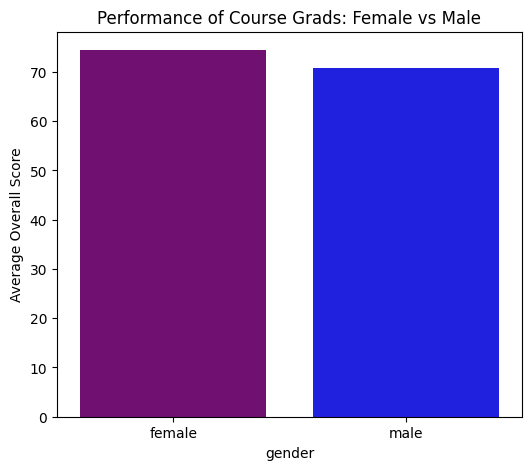

In [ ]:


hypothesis_result = prep_df.groupby('gender')['overall_score'].mean()

print("Average Overall Score for Students who COMPLETED the course:")
print(hypothesis_result)

plt.figure(figsize=(6, 5))
sns.barplot(x=hypothesis_result.index, y=hypothesis_result.values, palette=['purple', 'Blue'])
plt.title('Performance of Course Grads: Female vs Male')
plt.ylabel('Average Overall Score')
plt.show()

The chart shows that the female students who completed the preparation course achieved higher average grades than the male students, indicating a difference in academic performance between the genders after completing the course. This result suggests that the preparation course may be more effective for female students compared to male students.

Statistical Measurement: Skewness (Male vs. Female)

In [ ]:
#Objective: To measure the "skewness" of the overall score distribution.

# Skewness tells us whether most scores are high or low.

# ----------------------------------------------------------------------

# Calculate the skewness for female scores.

# A negative result (-0.33) indicates a "leftward skewness."

# Interpretation: Most female scores are concentrated in the upper range (good performance).

print(female[['overall_score']].skew())

# Calculate the skewness for male scores.

# A negative result (-0.17) also indicates a "leftward skewness."

# Comparison: The male score distribution is more symmetrical and less concentrated in high scores than the female score distribution.

print(male[['overall_score']].skew())


overall_score   -0.335717
dtype: float64
overall_score   -0.174353
dtype: float64


In [ ]:
# Objective: To calculate Pearson's correlation coefficient between 'overall_score' and itself (in female data).

# (Correlation measures the linear relationship between two variables).

# The result is 1.0 (perfect correlation), which is expected when comparing a variable to itself.

female[['overall_score']].corr(method='pearson')



,overall_score
overall_score,1.0


Correlation Analysis (Spearman's Method)

In [ ]:
# Objective: To calculate Spearman's correlation coefficient for the variable 'overall_score' with itself (in male data).

# Spearman's correlation coefficient measures the relationship based on the rank (order) of the scores.


male[['overall_score']].corr(method='spearman')

# Result: 1.0 (perfect correlation). This is the expected result when comparing a variable to itself.

,overall_score
overall_score,1.0
